# clustering days into groups based on 500 mb heights (or full variable datasets? can see how similar they are)

In [1]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter1d
from minisom import MiniSom
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from sklearn.metrics import silhouette_score
import matplotlib.gridspec as gridspec

In [2]:
weather = xr.open_dataset('data/raw_data/heights.nc')

In [3]:
z = weather['z'].load()/9.81  # (time, lat, lon)

z = z.squeeze('pressure_level')

# day-of-year climatology
climo = z.groupby('valid_time.dayofyear').mean('valid_time')

# smooth climatology (cyclic!)
climo_vals = climo.values  # (dayofyear, lat, lon)

climo_smooth = uniform_filter1d(
    climo_vals,
    size=15,
    axis=0,
    mode='wrap'
)

climo = xr.DataArray(
    climo_smooth,
    dims=climo.dims,
    coords=climo.coords
)

# anomalies
doy = z['valid_time'].dt.dayofyear
anom = z - climo.sel(dayofyear=doy)

In [4]:
p = anom.polyfit(dim='valid_time', deg=1)
trend = xr.polyval(anom['valid_time'], p.polyfit_coefficients)

anom_dt = anom - trend

In [5]:
# add selection of desired days
pph = xr.open_dataset('data/raw_data/labelled_pph.nc')
pph_time = pd.to_datetime(pph['time'].values, format='%Y%m%d%H%M')

cats = ['SLGT', 'ENH', 'MDT', 'HIGH']
mask = np.isin(pph['MAX_CAT'].values, cats) & (pph_time> '2002-03-30')

times_shifted = pph_time[mask] + np.timedelta64(1, 'D')

anom_dt = anom_dt.sel(valid_time=times_shifted)
anom = anom.sel(valid_time=times_shifted)

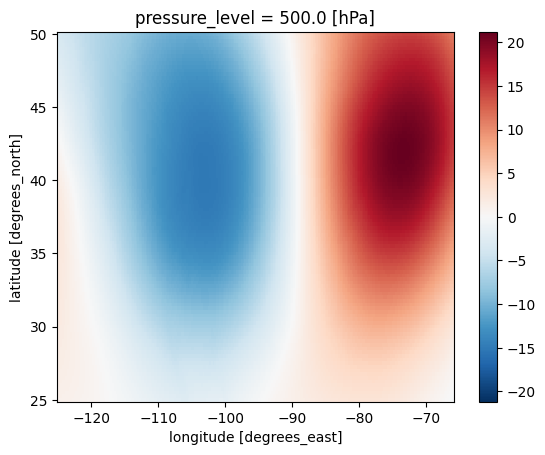

In [6]:
anom_dt.mean('valid_time').plot()

In [7]:
# latitude weight and prep
weights = np.sqrt(np.cos(np.deg2rad(anom_dt['latitude'])))
anom_w = anom_dt * weights

X = anom_w.stack(space=('latitude','longitude')).transpose('valid_time','space')

In [ ]:
# do PCA
pca = PCA(n_components=10)
PCs = pca.fit_transform(X)

In [9]:
# do som
som = MiniSom(4, 4, PCs.shape[1], sigma=1.0, learning_rate=0.5)
som.train(PCs, 10000)

labels_som = np.array([som.winner(x) for x in PCs])

In [10]:
def composite(labels):
    # convert 2D SOM indices -> single 1D cluster id
    if labels.ndim == 2:
        # make each (i,j) pair a unique integer
        ncols = labels[:,1].max() + 1
        labels_1d = labels[:,0] * ncols + labels[:,1]
    else:
        labels_1d = labels

    comps = []
    for k in np.unique(labels_1d):
        idx = np.where(labels_1d == k)[0]
        comps.append(anom.isel(valid_time=idx).mean('valid_time'))

    return xr.concat(comps, dim='cluster')

In [11]:
outlooks = xr.open_dataset('data/raw_data/grid_outlooks.nc')
reports = xr.open_dataset('data/raw_data/grid_reports.nc')

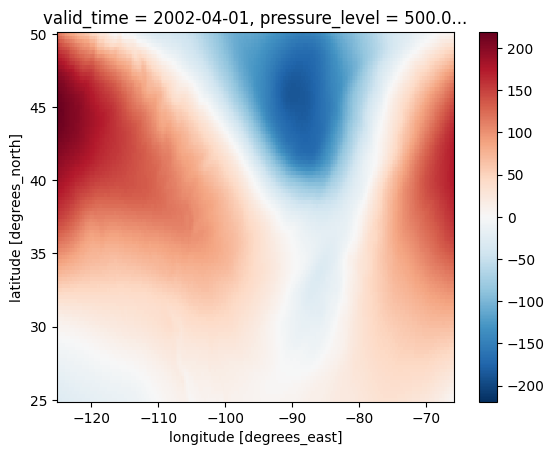

In [18]:
anom_dt.isel(valid_time=0).plot()

KMeans k= 4  silhouette=0.1239


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


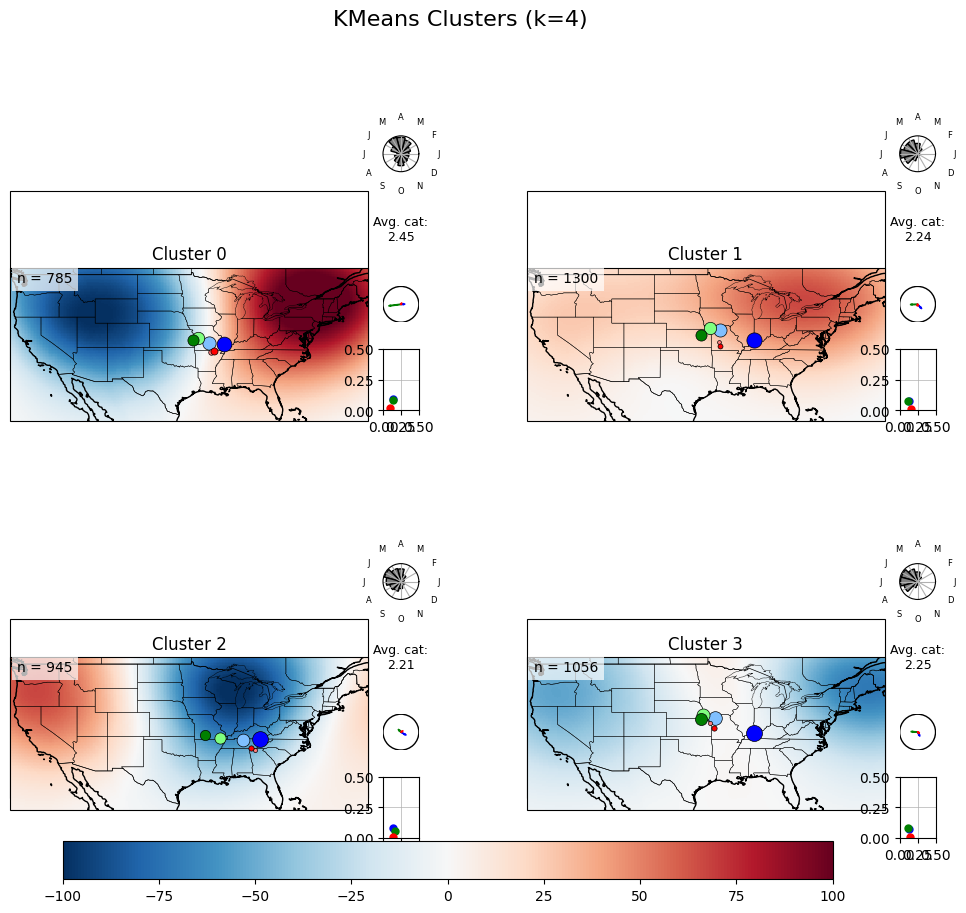

KMeans k= 9  silhouette=0.1004


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


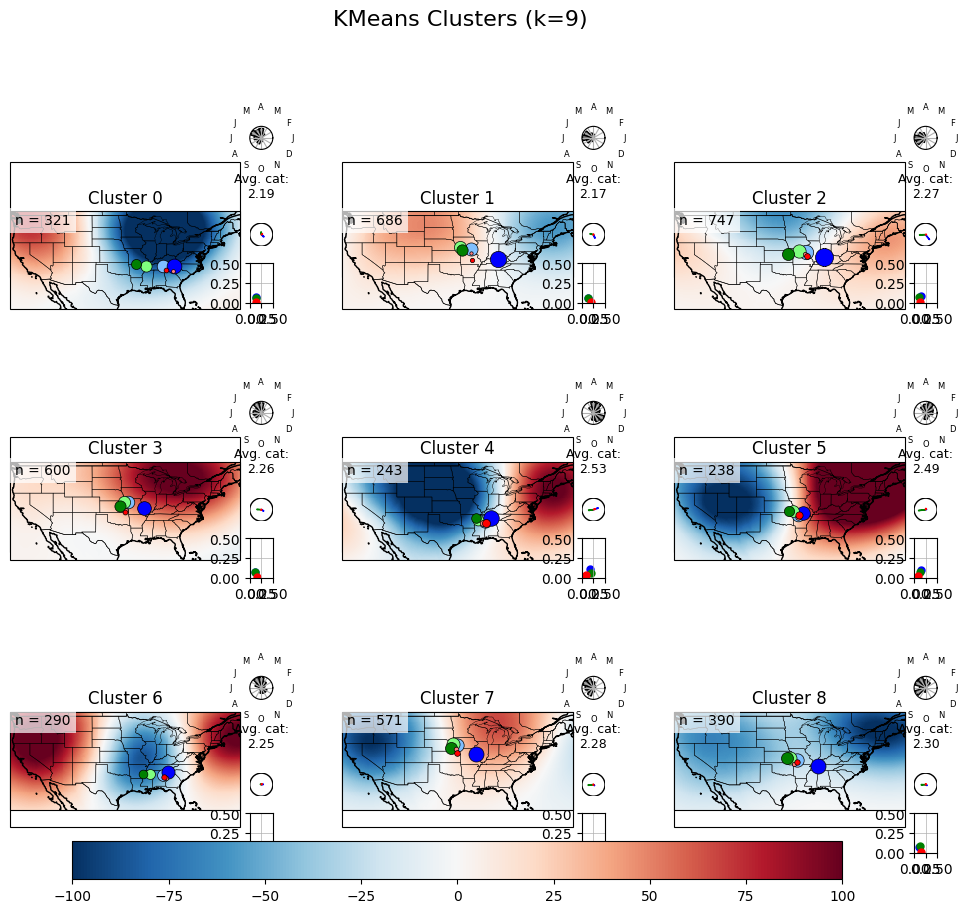

KMeans k=16  silhouette=0.0847


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


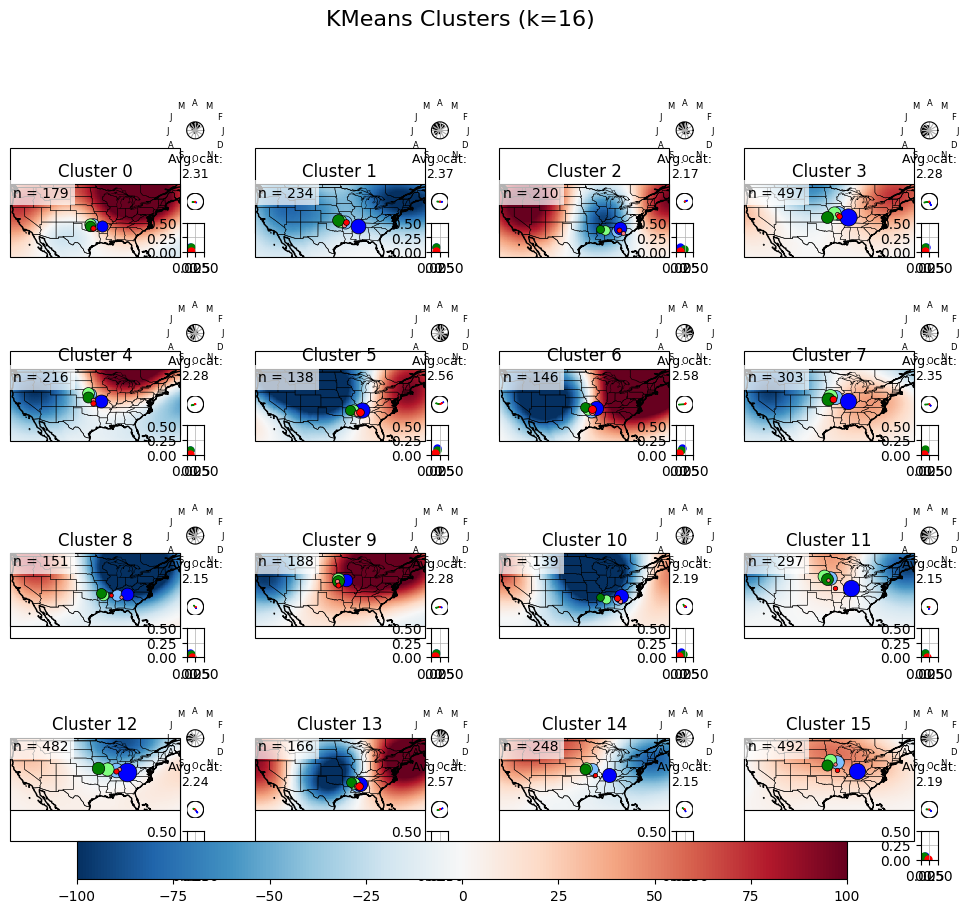

In [23]:
# finding best clustering systematically
best_km = {
    'score': -np.inf,
    'k': None,
    'labels': None,
    'model': None
}

scores = []
for k in [4, 9, 16]:
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(PCs)
    score = silhouette_score(PCs, labels)
    print(f"KMeans k={k:2d}  silhouette={score:0.4f}")

    if score > best_km['score']:
        best_km.update({
            'score': score,
            'k': k,
            'labels': labels,
            'model': km
        })
    scores.append(score)

    comp_km = composite(labels)

    n = int(np.ceil(np.sqrt(k)))

    fig = plt.figure(figsize=(12, 10))
    outer = gridspec.GridSpec(n, n, figure=fig, wspace=0.25, hspace=0.25)

    counts = np.bincount(labels, minlength=k)

    map_axes = []

    for i in range(k):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, 2,
            subplot_spec=outer[i],
            width_ratios=[8, 1],   # big map, thin diagnostic strip
            wspace=0.05
        )

        ax = fig.add_subplot(inner[0], projection=ccrs.PlateCarree())
        ax = fig.add_subplot(inner[0], projection=ccrs.PlateCarree())
        side = fig.add_subplot(inner[1])   # placeholder only
        side.axis('off')

        map_axes.append(ax)

        x0, w = 0.10, 0.80
        h = 0.18
        gap = 0.04
        ys = [1 - (k+1)*(h+gap) for k in range(4)]

        ax_rose    = side.inset_axes([x0, ys[0], w, h], polar=True)
        ax_maxcat  = side.inset_axes([x0, ys[1], w, h])
        ax_compass = side.inset_axes([x0, ys[2], w, h])
        ax_skill   = side.inset_axes([x0, ys[3], w, h])
        field = comp_km.isel(cluster=i)

        im = ax.pcolormesh(
            field['longitude'],
            field['latitude'],
            field,
            transform=ccrs.PlateCarree(),
            cmap='RdBu_r',
            vmin = -100,
            vmax = 100
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.3)

        ax.set_title(f'Cluster {i}')

        # add member count in corner
        ax.text(
            0.02, 0.98,
            f'n = {counts[i]}',
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

                # ----- six centroid markers (outlooks + reports) -----

        # times in this cluster
        idx = np.where(labels == i)[0]
        times = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')
        # convert datetime64 -> 'YYYYMMDD0000' strings to match outlooks/reports
        times_str = (
            times.dt.strftime('%Y%m%d') + '0000'
        ).values

        # mean fields over cluster times
        ol = outlooks.sel(time=times_str).mean('time')
        if i == 0:
            saved_ol = ol
        rp = reports.sel(time=times_str).mean('time')

        lat = outlooks['lat']
        lon = outlooks['lon']


        def centroid_and_size(weight, power = 2):
            wsum = (weight**power).sum()
            clat = ((weight**power) * lat).sum() / wsum
            clon = ((weight**power) * lon).sum() / wsum
            return float(clon), float(clat), float(weight.sum())

        # outlook weights
        w_ol_wind = ol['prob'].sel(outlook='Day 1 Wind')
        w_ol_hail = ol['prob'].sel(outlook='Day 1 Hail')
        w_ol_tor  = ol['prob'].sel(outlook='Day 1 Tornado')

        # report weights
        w_rp_wind = rp['bool'].sel(hazard='Wind')
        w_rp_hail = rp['bool'].sel(hazard='Hail')
        w_rp_tor  = rp['bool'].sel(hazard='Tornado')

        scale = 5  # adjust as needed

        for w, color in [
            (w_ol_wind, '#7fbfff'),   # light blue
            (w_rp_wind, 'blue'),
            (w_ol_hail, '#7fff7f'),   # light green
            (w_rp_hail, 'green'),
            (w_ol_tor,  '#ff7f7f'),   # light red
            (w_rp_tor,  'red'),
        ]:
            clon, clat, size = centroid_and_size(w)
            ax.scatter(
                clon, clat,
                s=size * scale,
                color=color,
                transform=ccrs.PlateCarree(),
                zorder=10,
                edgecolor='k',
                linewidth=0.5
            )

        # --- Cluster times ---
        times_cluster = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')

        # convert to string format for indexing pph/outlooks/reports
        times_str = (times_cluster.dt.strftime('%Y%m%d') + '0000').values

        # --- Vertical strip inset coordinates ---
        # bbox = [x0, y0, width, height] in figure fraction
        # we will make 4 stacked insets, each 0.2 in height
        fig = ax.figure
        bbox_base = ax.get_position()  # [x0, y0, width, height]
        x0 = bbox_base.x1 + 0.01       # slightly to the right
        y0 = bbox_base.y0
        width = 0.08
        height = bbox_base.height / 4   # each inset

        # --- 1. Seasonal rose (polar) ---
        months = times_cluster.dt.month.values
        month_counts = np.bincount(months-1, minlength=12)
        angles = np.linspace(0, 2*np.pi, 12, endpoint=False)

        ax_rose.bar(angles, month_counts, width=2*np.pi/12, color='gray', edgecolor='k')
        ax_rose.set_xticks(angles)
        ax_rose.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
        ax_rose.set_yticks([])

        # --- 2. Avg MAX_CAT ---
        max_cat_map = {'SLGT':2, 'ENH': 3, 'MDT':4, 'HIGH':5}
        vals = np.array([max_cat_map[c] for c in pph.MAX_CAT.sel(time=times_str).values])
        avg_cat = np.nanmean(vals)
        ax_maxcat.axis('off')
        ax_maxcat.text(0.5, 0.5, f"Avg. cat:\n{avg_cat:.2f}",
               ha='center', va='center', fontsize=9)

        # --- 3. Compass vectors ---
        #ax_compass = fig.add_axes([x0, y0 + height, width, height])
        ax_compass.set_aspect('equal')
        ax_compass.set_xlim(-1,1)
        ax_compass.set_ylim(-1,1)

        circle = plt.Circle((0,0), 1, fill=False, color='k', lw=1)
        ax_compass.add_patch(circle)

        for color, e_var, n_var in zip(
                ['blue','green','red'],
                ['E_SH_W_NUM','E_SH_H_NUM','E_SH_T_NUM'],
                ['N_SH_W_NUM','N_SH_H_NUM','N_SH_T_NUM']):
            e = pph[e_var].sel(time=times_str).mean().item()
            n = pph[n_var].sel(time=times_str).mean().item()
            #print(e, n)
            ax_compass.arrow(
                0, 0, e/100000, n/100000,
                color=color, width=0.03,
                length_includes_head=True,
                head_width=.08
            )

        ax_compass.axis('off')

        # --- 4. Skill points ---
        #ax_skill = fig.add_axes([x0, y0, width, height])
        ax_skill.set_xlim(0,0.5)
        ax_skill.set_ylim(0,0.5)
        ax_skill.set_xticks([0,0.25,0.5])
        ax_skill.set_yticks([0,0.25,0.5])
        ax_skill.grid(True, lw=0.5)

        for color, far_var, pod_var in zip(
                ['blue','green','red'],
                ['FAR_W_NUM','FAR_H_NUM','FAR_T_NUM'],
                ['POD_W_NUM','POD_H_NUM','POD_T_NUM']):
            x = (1 - pph[far_var].sel(time=times_str).mean())
            y = pph[pod_var].sel(time=times_str).mean()
            ax_skill.scatter(x, y, color=color, s=25)

        for spine in ax_skill.spines.values():
            spine.set_visible(True)

    # shared colorbar
    fig.colorbar(
        im,
        ax=map_axes,
        orientation='horizontal',
        pad=0.04,
        fraction=0.05
    )

    fig.suptitle(f'KMeans Clusters (k={k})', fontsize=16)

    plt.show()

SOM 3x3 sigma=0.5 lr=0.25  silhouette=0.0881


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


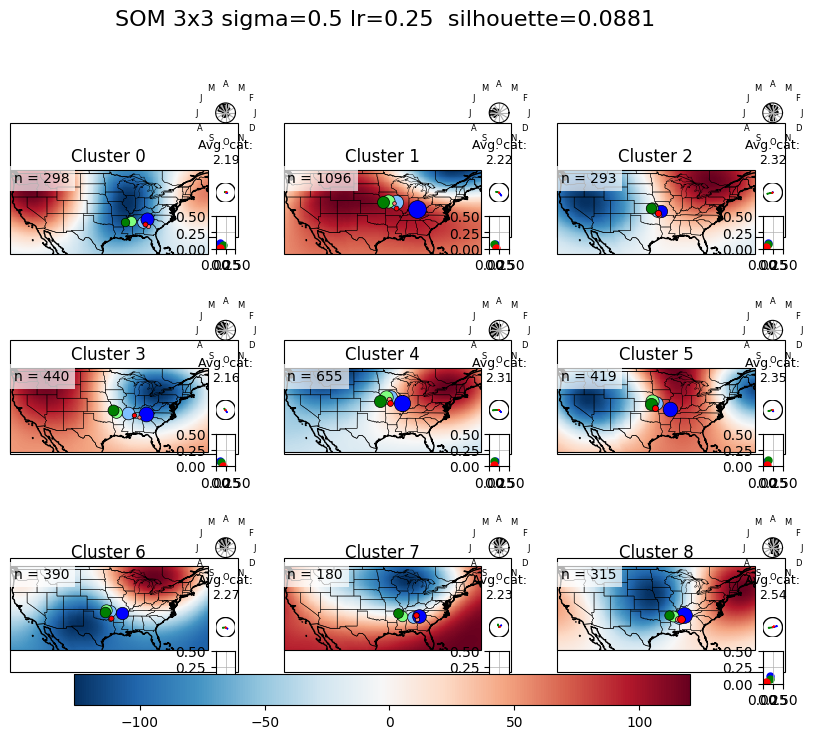

SOM 3x3 sigma=0.5 lr=0.5  silhouette=0.0734


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


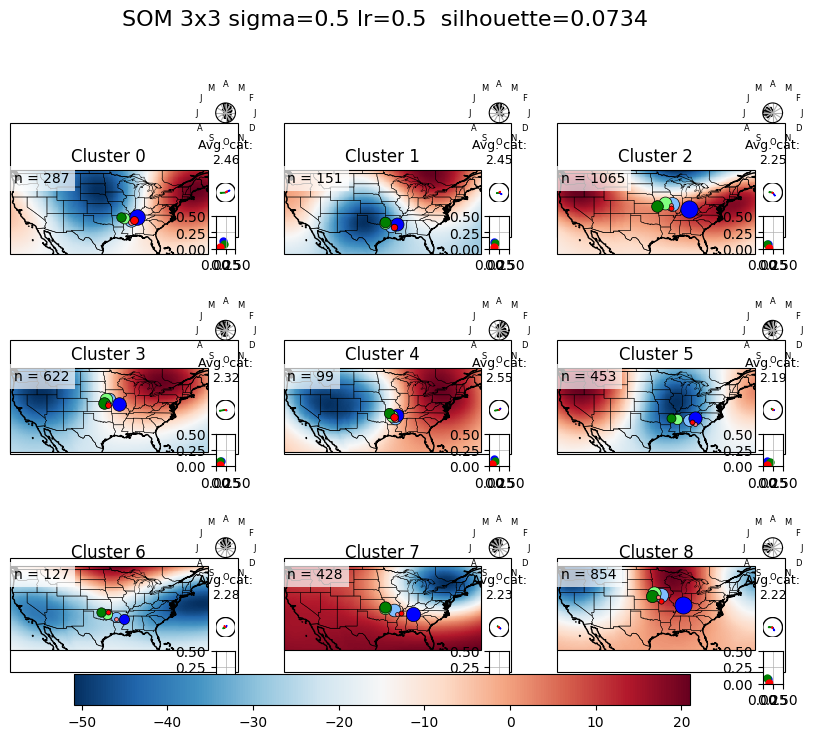

SOM 3x3 sigma=0.5 lr=1  silhouette=0.0656


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


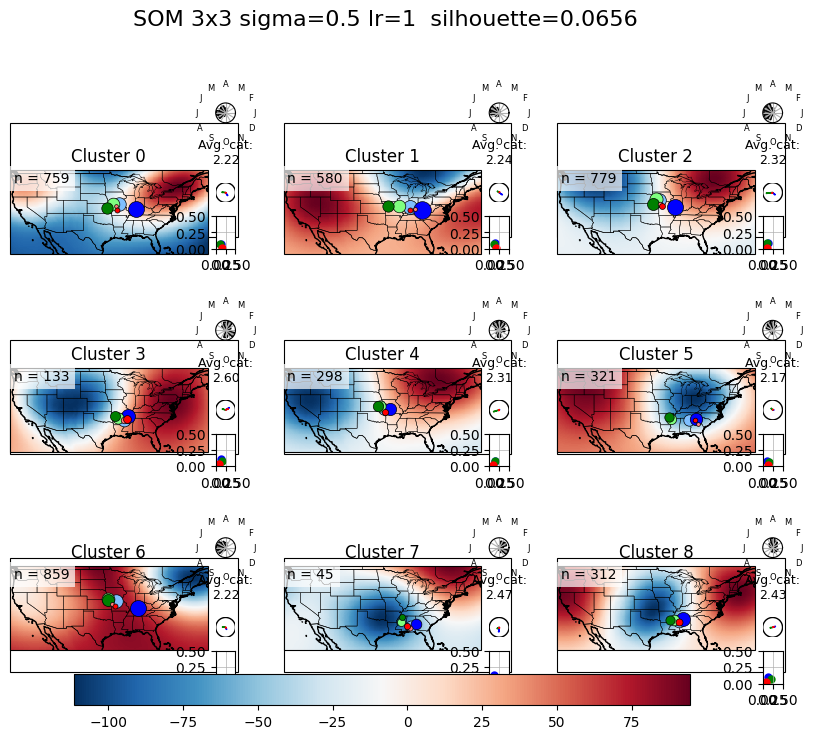

SOM 3x3 sigma=1.0 lr=0.25  silhouette=0.0690


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


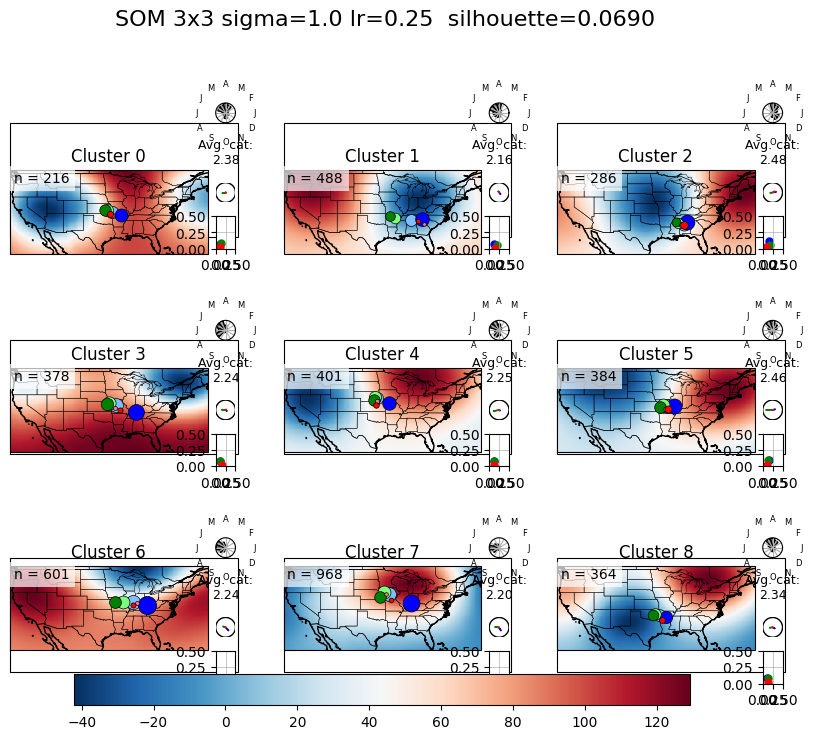

SOM 3x3 sigma=1.0 lr=0.5  silhouette=0.0793


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


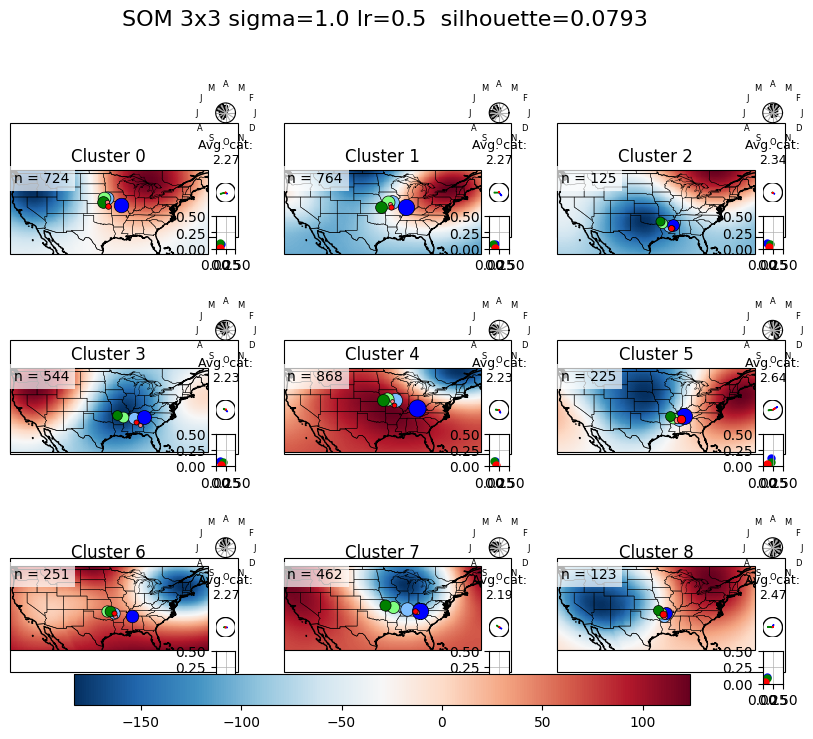

SOM 3x3 sigma=1.0 lr=1  silhouette=0.0737


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


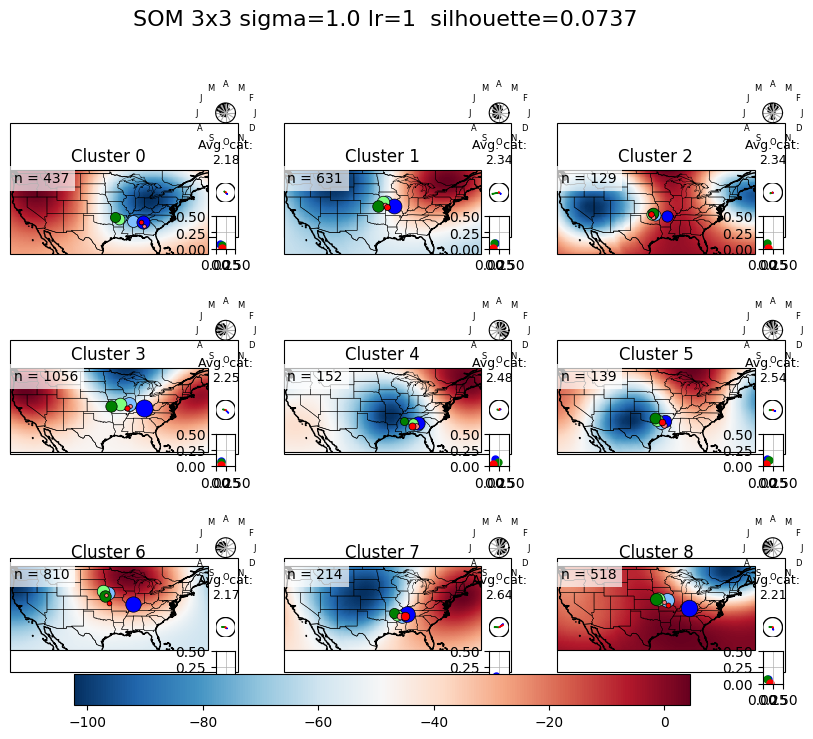

SOM 3x3 sigma=1.5 lr=0.25  silhouette=0.0257


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


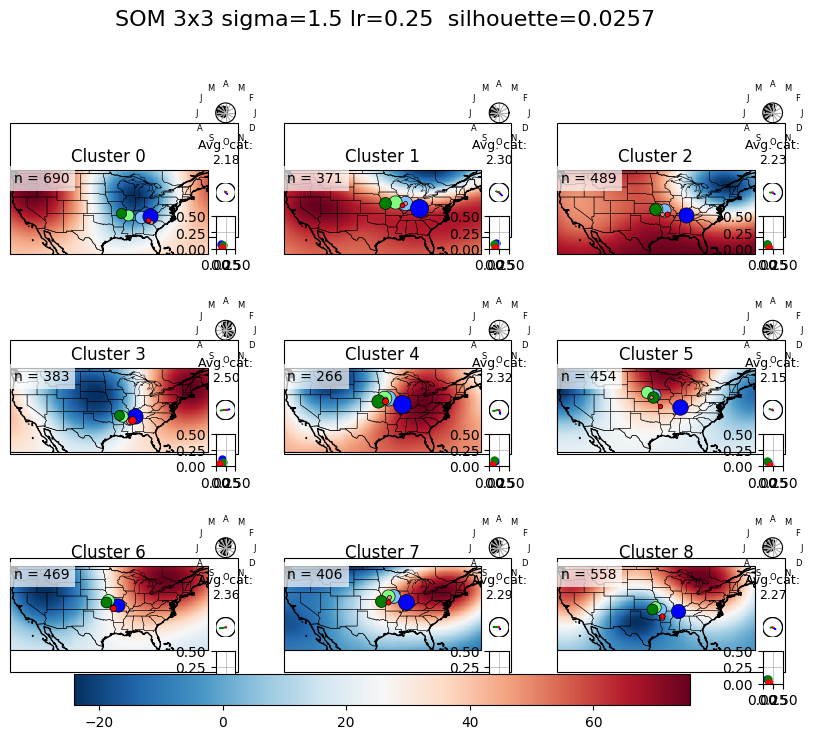

SOM 3x3 sigma=1.5 lr=0.5  silhouette=0.0384


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


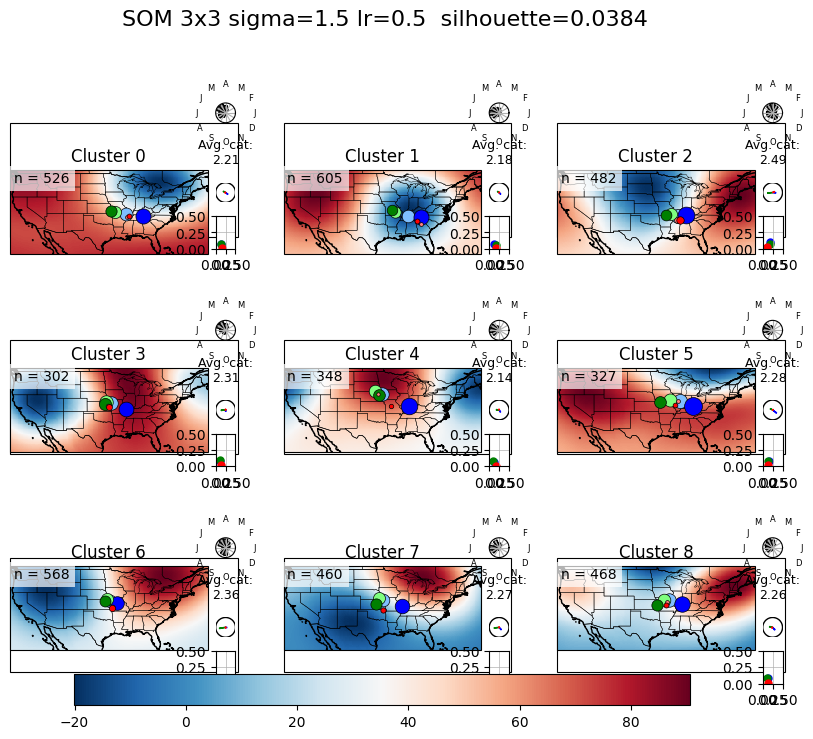

SOM 3x3 sigma=1.5 lr=1  silhouette=0.0207


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


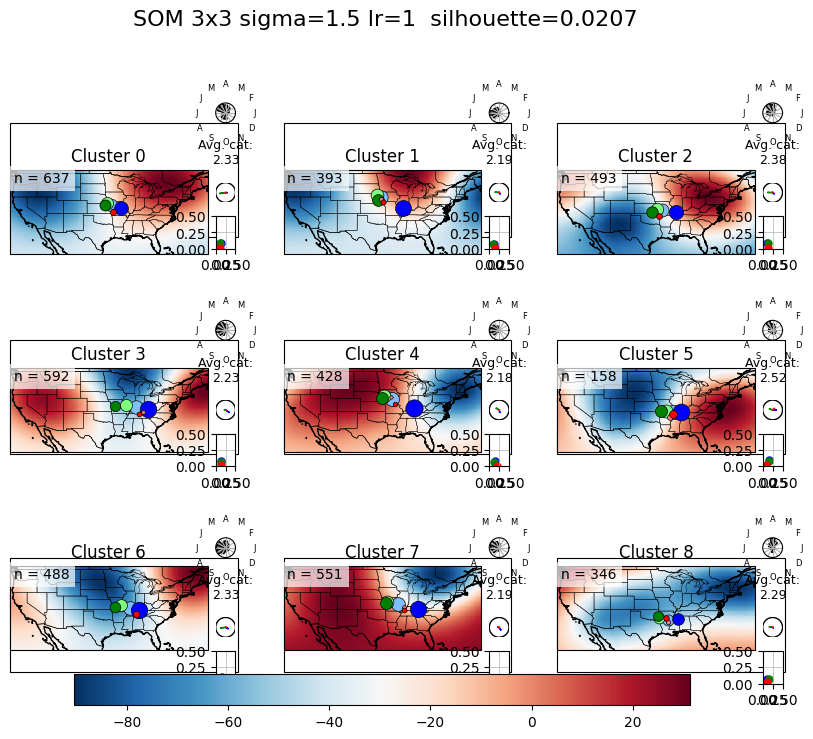


BEST SOM: (3, 3) 0.5 0.25 0.08813926204876263


In [ ]:
def som_labels(som, X):
    winners = np.array([som.winner(x) for x in X])
    # convert (i,j) -> single cluster id
    return winners[:,0] * som._weights.shape[1] + winners[:,1]

best_som = {
    'score': -np.inf,
    'shape': None,
    'sigma': None,
    'lr': None,
    'labels': None,
    'som': None
}

#for side_len in [2, 3, 4, 5]:          # 2x2, 3x3, ...
for sigma in [.5, 1.0, 1.5]:
    for lr in [.25, .5, 1]:

        som = MiniSom(3, 3, PCs.shape[1],
                        sigma=sigma, learning_rate=lr)

        som.train(PCs, 10000)

        labels = som_labels(som, PCs)
        score = silhouette_score(PCs, labels)

        print(f"SOM {3}x{3} sigma={sigma} lr={lr}  silhouette={score:0.4f}")

        if score > best_som['score']:
            best_som.update({
                'score': score,
                'shape': (3, 3),
                'sigma': sigma,
                'lr': lr,
                'labels': labels,
                'som': som
            })
        comp_som = composite(labels)
        n_clusters = comp_som.sizes['cluster']

        fig, axes = plt.subplots(
            nrows=3, ncols=3,  
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        axes = axes.ravel()

        counts = np.bincount(labels, minlength=9)

        map_axes = []
        for i, ax in enumerate(axes[:n_clusters]):
            inner = gridspec.GridSpecFromSubplotSpec(
                1, 2,
                subplot_spec=ax.get_subplotspec(),  # use this axes as parent
                width_ratios=[8, 1],
                wspace=0.05
            )

            ax = fig.add_subplot(inner[0], projection=ccrs.PlateCarree())
            side = fig.add_subplot(inner[1])   # placeholder only
            side.axis('off')

            map_axes.append(ax)

            x0, w = 0.10, 0.80
            h = 0.18
            gap = 0.04
            ys = [1 - (k+1)*(h+gap) for k in range(4)]

            ax_rose    = side.inset_axes([x0, ys[0], w, h], polar=True)
            ax_maxcat  = side.inset_axes([x0, ys[1], w, h])
            ax_compass = side.inset_axes([x0, ys[2], w, h])
            ax_skill   = side.inset_axes([x0, ys[3], w, h])
            
            field = comp_som.isel(cluster=i)

            im = ax.pcolormesh(
                field['longitude'],
                field['latitude'],
                field,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r'
            )

            ax.coastlines()
            ax.add_feature(cfeature.BORDERS, linewidth=0.5)
            ax.add_feature(cfeature.STATES, linewidth=0.3)

            ax.set_title(f'Cluster {i}')
            # add member count in corner
            ax.text(
                0.02, 0.98,
                f'n = {counts[i]}',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

                        # ----- six centroid markers (outlooks + reports) -----

            # times in this cluster
            idx = np.where(labels == i)[0]
            times = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')
            # convert datetime64 -> 'YYYYMMDD0000' strings to match outlooks/reports
            times_str = (
                times.dt.strftime('%Y%m%d') + '0000'
            ).values

            # mean fields over cluster times
            ol = outlooks.sel(time=times_str).mean('time')
            if i == 0:
                saved_ol = ol
            rp = reports.sel(time=times_str).mean('time')

            lat = outlooks['lat']
            lon = outlooks['lon']


            def centroid_and_size(weight, power = 2):
                wsum = (weight**power).sum()
                clat = ((weight**power) * lat).sum() / wsum
                clon = ((weight**power) * lon).sum() / wsum
                return float(clon), float(clat), float(weight.sum())

            # outlook weights
            w_ol_wind = ol['prob'].sel(outlook='Day 1 Wind')
            w_ol_hail = ol['prob'].sel(outlook='Day 1 Hail')
            w_ol_tor  = ol['prob'].sel(outlook='Day 1 Tornado')

            # report weights
            w_rp_wind = rp['bool'].sel(hazard='Wind')
            w_rp_hail = rp['bool'].sel(hazard='Hail')
            w_rp_tor  = rp['bool'].sel(hazard='Tornado')

            scale = 5  # adjust as needed

            for w, color in [
                (w_ol_wind, '#7fbfff'),   # light blue
                (w_rp_wind, 'blue'),
                (w_ol_hail, '#7fff7f'),   # light green
                (w_rp_hail, 'green'),
                (w_ol_tor,  '#ff7f7f'),   # light red
                (w_rp_tor,  'red'),
            ]:
                clon, clat, size = centroid_and_size(w)
                ax.scatter(
                    clon, clat,
                    s=size * scale,
                    color=color,
                    transform=ccrs.PlateCarree(),
                    zorder=10,
                    edgecolor='k',
                    linewidth=0.5
                )

            # --- Cluster times ---
            times_cluster = anom.valid_time.isel(valid_time=idx) - np.timedelta64(1, 'D')

            # convert to string format for indexing pph/outlooks/reports
            times_str = (times_cluster.dt.strftime('%Y%m%d') + '0000').values

            # --- Vertical strip inset coordinates ---
            # bbox = [x0, y0, width, height] in figure fraction
            # we will make 4 stacked insets, each 0.2 in height
            fig = ax.figure
            bbox_base = ax.get_position()  # [x0, y0, width, height]
            x0 = bbox_base.x1 + 0.01       # slightly to the right
            y0 = bbox_base.y0
            width = 0.08
            height = bbox_base.height / 4   # each inset

            # --- 1. Seasonal rose (polar) ---
            months = times_cluster.dt.month.values
            month_counts = np.bincount(months-1, minlength=12)
            angles = np.linspace(0, 2*np.pi, 12, endpoint=False)

            ax_rose.bar(angles, month_counts, width=2*np.pi/12, color='gray', edgecolor='k')
            ax_rose.set_xticks(angles)
            ax_rose.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
            ax_rose.set_yticks([])

            # --- 2. Avg MAX_CAT ---
            max_cat_map = {'SLGT':2, 'ENH': 3, 'MDT':4, 'HIGH':5}
            vals = np.array([max_cat_map[c] for c in pph.MAX_CAT.sel(time=times_str).values])
            avg_cat = np.nanmean(vals)
            ax_maxcat.axis('off')
            ax_maxcat.text(0.5, 0.5, f"Avg. cat:\n{avg_cat:.2f}",
                ha='center', va='center', fontsize=9)

            # --- 3. Compass vectors ---
            #ax_compass = fig.add_axes([x0, y0 + height, width, height])
            ax_compass.set_aspect('equal')
            ax_compass.set_xlim(-1,1)
            ax_compass.set_ylim(-1,1)

            circle = plt.Circle((0,0), 1, fill=False, color='k', lw=1)
            ax_compass.add_patch(circle)

            for color, e_var, n_var in zip(
                    ['blue','green','red'],
                    ['E_SH_W_NUM','E_SH_H_NUM','E_SH_T_NUM'],
                    ['N_SH_W_NUM','N_SH_H_NUM','N_SH_T_NUM']):
                e = pph[e_var].sel(time=times_str).mean().item()
                n = pph[n_var].sel(time=times_str).mean().item()
                #print(e, n)
                ax_compass.arrow(
                    0, 0, e/100000, n/100000,
                    color=color, width=0.03,
                    length_includes_head=True,
                    head_width=.08
                )

            ax_compass.axis('off')

            # --- 4. Skill points ---
            #ax_skill = fig.add_axes([x0, y0, width, height])
            ax_skill.set_xlim(0,0.5)
            ax_skill.set_ylim(0,0.5)
            ax_skill.set_xticks([0,0.25,0.5])
            ax_skill.set_yticks([0,0.25,0.5])
            ax_skill.grid(True, lw=0.5)

            for color, far_var, pod_var in zip(
                    ['blue','green','red'],
                    ['FAR_W_NUM','FAR_H_NUM','FAR_T_NUM'],
                    ['POD_W_NUM','POD_H_NUM','POD_T_NUM']):
                x = (1 - pph[far_var].sel(time=times_str).mean())
                y = pph[pod_var].sel(time=times_str).mean()
                ax_skill.scatter(x, y, color=color, s=25)

            for spine in ax_skill.spines.values():
                spine.set_visible(True)

        # shared colorbar
        fig.colorbar(
            im,
            ax=map_axes,
            orientation='horizontal',
            pad=0.04,
            fraction=0.05
        )

        fig.suptitle(f"SOM {3}x{3} sigma={sigma} lr={lr}  silhouette={score:0.4f}", fontsize=16)

        plt.show()

print("\nBEST SOM:", best_som['shape'], best_som['sigma'], best_som['lr'], best_som['score'])